In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt



In [3]:
BATCH_SIZE = 32;
IMAGE_SIZE = (256,256);
CHANNELS = 3;
EPOCHS = 50;

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "D:\Projects new😘\Potato disease\Data set",
    shuffle = True,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE 

)

Found 2152 files belonging to 3 classes.


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mahes\AppData\Local\Temp\ipykernel_6060\1058703814.py:2: SyntaxWarning: invalid escape sequence '\P'
  "D:\Projects new😘\Potato disease\Data set",


In [5]:
# Get the class names from the dataset 
class_names = dataset.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [6]:
dataset.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

(32, 256, 256, 3)
[2 1 1 0 1 1 1 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 0 1 2 1 1 2 0 1 1]


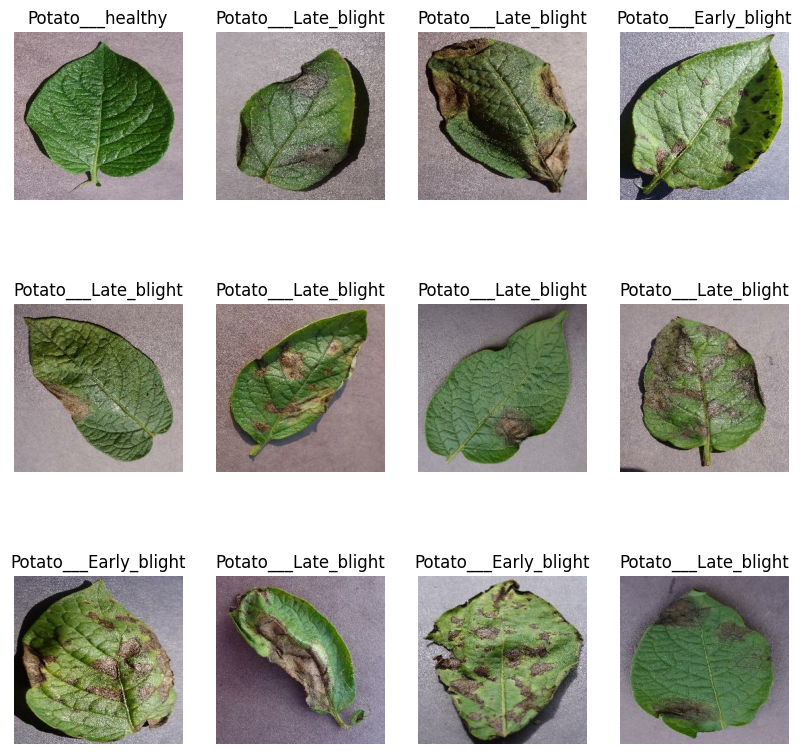

In [7]:
plt.figure(figsize = (10,10))
for image_batch,labels_batch in dataset.take(1):

    print(image_batch.shape)
    print(labels_batch.numpy()) # here 0 = early blight, 1 = late blight, 2 = healthy
    for i in range(12): # there are a total of 12 images in the batch
        ax = plt.subplot(3,4,i+1) # 3 rows and 4 columns
        plt.imshow(image_batch[i].numpy().astype("uint8")) # convert the image to uint8 format for display
        plt.title(class_names[labels_batch[i]]) # set the title of the image to the class name   
        plt.axis("off")

In [8]:
# divide the dataset into training and validation sets
# 80% for the training and 20% for the testing
#in 20% testing the 10% for validation and 10% for testing

train_size = int(0.8 * len(dataset))
train_size


54

In [9]:
train_dataset = dataset.take(train_size)
len(train_dataset)

54

In [10]:
test_dataset_old = dataset.skip(train_size)
len(test_dataset_old)

14

In [11]:
val_size = int(0.1 * len(dataset))
validation_dataset = test_dataset_old.take(val_size)
len(validation_dataset)

6

In [12]:
test_dataset_new = test_dataset_old.skip(val_size)
len(test_dataset_new)

8

In [13]:
def get_dataset_partitions_tf(dataset, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1

    dataset_size = len(dataset)

    if shuffle:
        dataset = dataset.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)

    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size).take(val_size)
    test_ds = dataset.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds   

In [14]:
train_ds , val_ds, test_ds = get_dataset_partitions_tf(dataset)
len(train_ds), len(val_ds), len(test_ds)

(54, 6, 8)

In [15]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


In [16]:
for(image_batch, labels_batch) in dataset.take(1):
    print(image_batch[0])
    print(labels_batch.numpy()/255)


tf.Tensor(
[[[179. 177. 190.]
  [165. 163. 176.]
  [160. 158. 171.]
  ...
  [138. 139. 157.]
  [141. 142. 160.]
  [154. 155. 173.]]

 [[180. 178. 191.]
  [175. 173. 186.]
  [176. 174. 187.]
  ...
  [148. 149. 167.]
  [144. 145. 163.]
  [153. 154. 172.]]

 [[176. 174. 187.]
  [181. 179. 192.]
  [187. 185. 198.]
  ...
  [138. 139. 157.]
  [133. 134. 152.]
  [141. 142. 160.]]

 ...

 [[136. 134. 148.]
  [108. 106. 120.]
  [126. 124. 138.]
  ...
  [105. 108. 127.]
  [101. 104. 123.]
  [117. 120. 139.]]

 [[142. 140. 154.]
  [142. 140. 154.]
  [151. 149. 163.]
  ...
  [108. 111. 130.]
  [125. 128. 147.]
  [132. 135. 154.]]

 [[138. 136. 150.]
  [132. 130. 144.]
  [166. 164. 178.]
  ...
  [ 98. 101. 120.]
  [112. 115. 134.]
  [ 98. 101. 120.]]], shape=(256, 256, 3), dtype=float32)
[0.         0.         0.00784314 0.00392157 0.00784314 0.00392157
 0.         0.         0.         0.00392157 0.00392157 0.
 0.00392157 0.00392157 0.00784314 0.00784314 0.         0.00392157
 0.         0.       

In [17]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    layers.Rescaling(1.0 / 255)
])

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [19]:
input_shape = IMAGE_SIZE + (CHANNELS,)
model = models.Sequential([
    layers.Input(shape=input_shape),
    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.build(input_shape=(None,IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,899 (909.76 KB)

 Trainable params: 232,899 (909.76 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])

In [22]:
model.fit(train_ds, batch_size = BATCH_SIZE,validation_data=val_ds, verbose  = 1,epochs=15)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 907ms/step - accuracy: 0.4838 - loss: 0.8866 - val_accuracy: 0.5573 - val_loss: 0.7730
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 867ms/step - accuracy: 0.6881 - loss: 0.6722 - val_accuracy: 0.7552 - val_loss: 0.6392
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 879ms/step - accuracy: 0.7836 - loss: 0.5177 - val_accuracy: 0.8854 - val_loss: 0.2795
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8924 - loss: 0.2662 - val_accuracy: 0.9271 - val_loss: 0.3497
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 902ms/step - accuracy: 0.9242 - loss: 0.1921 - val_accuracy: 0.9479 - val_loss: 0.1622
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 872ms/step - accuracy: 0.9230 - loss: 0.1923 - val_accuracy: 0.9271 - val_loss: 0.2295
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 848ms/step - accuracy: 0.9473 - loss: 0.1360 - val_accuracy: 0.9062 - val_loss: 0.1802
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 851ms/step - accuracy: 0.9427 - loss: 0.1400 - val_accurac

First image to predict
Actual label:  Potato___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
Predicted label:  Potato___healthy


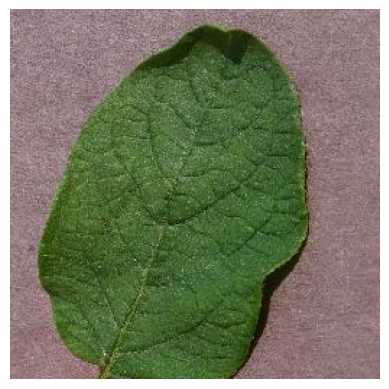

In [23]:
for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    print("First image to predict")
    plt.imshow(first_image)
    print("Actual label: ",class_names[labels_batch[0].numpy()])

    batch_prediction = model.predict(image_batch)
    print("Predicted label: ",class_names[tf.argmax(batch_prediction[0])])
    plt.axis("off")

In [24]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # create a batch

    predictions = model.predict(img_array)
    predicted_class = class_names[tf.argmax(predictions[0])]
    confidence = tf.reduce_max(tf.nn.softmax(predictions[0]))

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


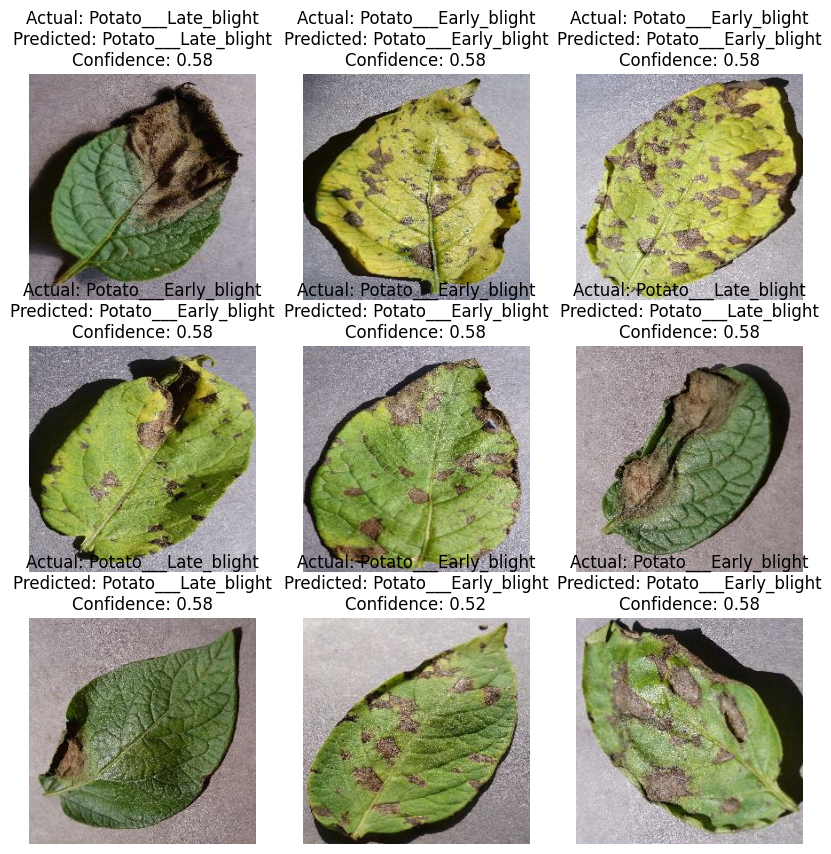

In [25]:
plt.figure(figsize = (10,10))
for image_batch ,label_batch in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model,image_batch[i].numpy())

        actual_class = class_names[label_batch[i].numpy()]
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}")
        plt.axis("off")

In [26]:
model.save("potato_disease_model.h5")


In [27]:
model.save("potato_disease_model.keras")

In [28]:
CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]